In [1]:
import jiwer
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def highlight_differences(true_text, pred_text):
    true_words = true_text.split()
    pred_words = pred_text.split()
    
    # Initialize lists for highlighted words
    highlighted = []
    print('true_words:', true_words)
    print('pred_words:', pred_words)
    # Compare words in true and predicted text
    max_len = max(len(true_words), len(pred_words))
    for i in range(max_len):
        pred_word = pred_words[i] if i < len(pred_words) else ""
        print('pred_word:', pred_word)
        if pred_word in true_words:
            highlighted.append(f"\033[92m{pred_word}\033[0m")  # Green for correct
        else:
            highlighted.append(f"\033[91m{pred_word}\033[0m")  # Red for incorrect

    return ' '.join(highlighted)

In [3]:
reference_text = "A memorable event from my childhood was the time I won first place in a school science fair with my homemade volcano project."
transcription = "memorable even from my childhood work time I want for play is gushan fair with my homemade volcano protest"

sentences_diff = highlight_differences(reference_text, transcription)
print(sentences_diff)

true_words: ['A', 'memorable', 'event', 'from', 'my', 'childhood', 'was', 'the', 'time', 'I', 'won', 'first', 'place', 'in', 'a', 'school', 'science', 'fair', 'with', 'my', 'homemade', 'volcano', 'project.']
pred_words: ['memorable', 'even', 'from', 'my', 'childhood', 'work', 'time', 'I', 'want', 'for', 'play', 'is', 'gushan', 'fair', 'with', 'my', 'homemade', 'volcano', 'protest']
pred_word: memorable
pred_word: even
pred_word: from
pred_word: my
pred_word: childhood
pred_word: work
pred_word: time
pred_word: I
pred_word: want
pred_word: for
pred_word: play
pred_word: is
pred_word: gushan
pred_word: fair
pred_word: with
pred_word: my
pred_word: homemade
pred_word: volcano
pred_word: protest
pred_word: 
pred_word: 
pred_word: 
pred_word: 
memorable even from my childhood work time I want for play is gushan fair with my homemade volcano protest    


In [4]:
import librosa
import numpy as np

def extract_features(audio_path):
    y, sr = librosa.load(audio_path, sr=None)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    return np.mean(mfccs, axis=1)

# Extract features from user and standard voice
user_features = extract_features('../uploads/recording.wav')
standard_features = extract_features('../uploads/voice-24080414:19.wav')


/var/folders/g6/37kt02914kx36yzcbbqfyck00000gn/T/ipykernel_57715/2730763177.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=None)
/Users/ngocp/Documents/projects/pyml/english-pronoun/myenv/lib/python3.10/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [5]:
user_path = '../uploads/recording.wav'
standard_path = '../uploads/voice-24080414:19.wav'

In [6]:
print(user_features)

[-453.69104    147.88512     17.393063    17.954575    32.4169
   19.716183    -6.681085    -5.9997854    0.8497603   -9.998926
  -10.920206    -4.058408    -4.9737115]


In [7]:
import torch
from transformers import Wav2Vec2Model, Wav2Vec2Tokenizer
from scipy.spatial.distance import cosine

# Load pre-trained model and tokenizer
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")
tokenizer = Wav2Vec2Tokenizer.from_pretrained("facebook/wav2vec2-base-960h")


/Users/ngocp/Documents/projects/pyml/english-pronoun/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'Wav2Vec2CTCTokenizer'. 
The class this function is called from is 'Wav2

In [8]:
def get_embedding(audio_path):
    audio_input = tokenizer(audio_path, return_tensors="pt").input_values
    with torch.no_grad():
        embedding = model(audio_input).last_hidden_state.mean(dim=1)
    return embedding.numpy().flatten()

user_embedding = get_embedding(user_path)
standard_embedding = get_embedding(standard_path)

# Compare embeddings
similarity = 1 - cosine(user_embedding, standard_embedding)
print(f"Embedding Cosine Similarity: {similarity}")

UFuncTypeError: ufunc 'add' did not contain a loop with signature matching types (dtype('<U24'), dtype('<U24')) -> None

/Users/ngocp/.pyenv/versions/3.10.3/lib/python3.10/site-packages/lazy_loader/__init__.py:185: RuntimeWarning: subpackages can technically be lazily loaded, but it causes the package to be eagerly loaded even if it is already lazily loaded.So, you probably shouldn't use subpackages with this lazy feature.
  warnings.warn(msg, RuntimeWarning)
/Users/ngocp/.pyenv/versions/3.10.3/lib/python3.10/site-packages/lazy_loader/__init__.py:185: RuntimeWarning: subpackages can technically be lazily loaded, but it causes the package to be eagerly loaded even if it is already lazily loaded.So, you probably shouldn't use subpackages with this lazy feature.
  warnings.warn(msg, RuntimeWarning)
/var/folders/g6/37kt02914kx36yzcbbqfyck00000gn/T/ipykernel_52863/1203535646.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=None)  # y is the audio time series, sr is the sample rate
/Users/ngocp/.pyenv/versions/3.10.3/lib/python3.10/site-packages/librosa/cor

D: (1025, 670) [ 1.27009585e-01+0.j  1.81193680e-01+0.j  4.20477428e-02+0.j
  3.50369327e-02+0.j  1.30346818e-02+0.j -6.26873691e-03+0.j
 -6.93492545e-03+0.j -5.45447245e-02+0.j -3.43247913e-02+0.j
 -4.87337746e-02+0.j -2.09607556e-03+0.j  2.54555289e-02+0.j
  2.13005915e-02+0.j  6.90040644e-03+0.j -4.72505167e-02+0.j
 -6.19706586e-02+0.j -3.89232226e-02+0.j -2.87283584e-02+0.j
 -1.40889231e-02+0.j -2.08119322e-02+0.j -5.88489473e-02+0.j
 -4.32717130e-02+0.j -2.76146713e-03+0.j -1.78330839e-02+0.j
  1.50034558e-02+0.j  6.62722811e-02+0.j -1.55870349e-03+0.j
 -4.18075584e-02+0.j -2.41222456e-02+0.j -9.73935518e-03+0.j
 -1.03339879e-02+0.j -4.71583679e-02+0.j -7.20186606e-02+0.j
 -8.61553922e-02+0.j -4.51299958e-02+0.j  2.30211802e-02+0.j
  3.42016555e-02+0.j  2.99291629e-02+0.j  1.06433388e-02+0.j
  4.17234097e-03+0.j  3.28476867e-03+0.j -9.85090621e-03+0.j
  5.38108358e-03+0.j  1.88902300e-03+0.j -9.71966330e-03+0.j
 -1.41685857e-02+0.j  3.83159553e-04+0.j  1.20600807e-02+0.j
  5.84862

AttributeError: module 'matplotlib' has no attribute 'axes'

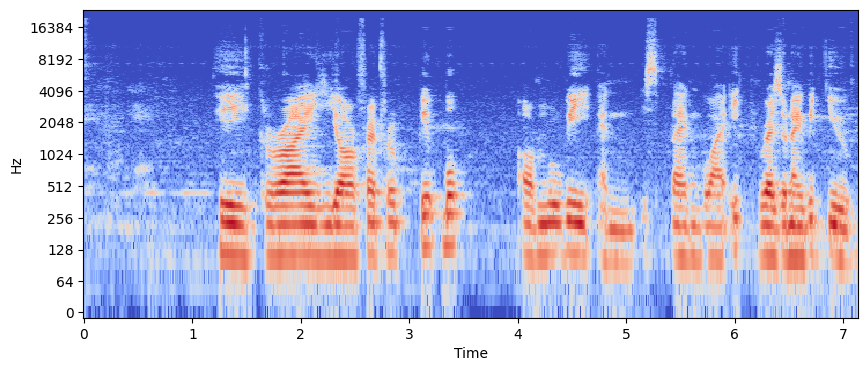

AttributeError: module 'matplotlib' has no attribute 'pyplot'

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np


def plot_spectrogram(audio_path):
    y, sr = librosa.load(audio_path, sr=None)  # y is the audio time series, sr is the sample rate

    # Compute the Short-Time Fourier Transform (STFT)
    D = librosa.stft(y)  # Compute the STFT
    print('D:', D.shape, D[0])
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)  # Convert to decibels

    # Plot the spectrogram
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log', cmap='coolwarm')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Spectrogram')
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.tight_layout()
    plt.show()


# Example usage
plot_spectrogram('../uploads/recording.wav')
